<a href="https://colab.research.google.com/github/MohammadAhmadSiddiqui/Capgemini-Training-/blob/main/Quesyion_18_Capstone_Project_3%264.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CAPSTONE PROJECT 3
Smart Marketing Prediction System (ML Pipeline Project)
Scenario
A fast-growing e-commerce company called ShopEasy is struggling with inefficient marketing campaigns.

Every day thousands of users visit their website. The marketing team spends a large amount of money showing ads, discounts, and promotional emails, but they don't know which customers are actually likely to buy something.

Currently:

Many customers browse but never purchase

Marketing money is wasted on the wrong users

The company wants to predict purchase probability

The data science team has been asked to build a machine learning system that predicts whether a customer will purchase a product during a session.

If the system predicts high probability of purchase, the system will:

show personalized product recommendations

offer targeted discounts

prioritize marketing campaigns

If the system predicts low probability, the company will avoid spending marketing resources.

However, the dataset contains both numerical and categorical features, so the data science team must design a complete ML pipeline.

Dataset is available in DatasetCapstoneProject3 in the github repo link https://github.com/himanshusar123/Datasets

Business Objective
Build a machine learning model that predicts whether a user will purchase (1) or not purchase (0) during a website session.

The model must be implemented using scikit-learn pipelines, including:

Encoding techniques

Feature preprocessing

Model training

Model selection

Hyperparameter tuning

In [2]:
from google.colab import files
uploaded = files.upload()

Saving DatasetCapstoneProject3.xlsx to DatasetCapstoneProject3.xlsx


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_excel("DatasetCapstoneProject3.xlsx")
print(df.head())
print(df.info())

X = df.drop("Purchased", axis=1)
y = df["Purchased"]
categorical_features = ["Gender","Device","Traffic_Source"]
numerical_features = ["Age","Time_on_Website","Pages_Visited","Ad_Clicks","Previous_Purchases"]
numerical_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier())
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

new_customer = pd.DataFrame({
    "Age":[30],
    "Gender":["Male"],
    "Device":["Mobile"],
    "Traffic_Source":["Social Media"],
    "Time_on_Website":[10],
    "Pages_Visited":[5],
    "Ad_Clicks":[2],
    "Previous_Purchases":[1]
})

prediction = best_model.predict(new_customer)

print("Purchase Prediction:", prediction)

   CustomerID  Age  Gender   Device  Traffic_Source  Time_on_Website  \
0           1   23    Male   Mobile    Social Media                5   
1           2   35  Female  Desktop   Search Engine               12   
2           3   29    Male   Tablet    Social Media                8   
3           4   41  Female   Mobile  Email Campaign               15   
4           5   22  Female  Desktop          Direct                4   

   Pages_Visited  Ad_Clicks  Previous_Purchases  Purchased  
0              3          1                   0          0  
1              8          3                   2          1  
2              5          2                   1          0  
3             10          4                   3          1  
4              2          0                   0          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0

#Capstone Project 4
Project Scenario

Smart Traffic Sign Recognition System

Scenario

A city is building a Smart Traffic Monitoring System to improve road safety.

Every intersection in the city will have cameras that detect traffic signs automatically.

The system must recognize different road signs such as:

Stop sign

Speed limit sign

Pedestrian crossing sign

The system will be used in autonomous vehicles and traffic monitoring cameras.

However, the engineers discovered two challenges:

1️⃣ First, the system must understand basic classification logic (learning from features).

2️⃣ Second, it must classify images of traffic signs captured by cameras.

To solve this, the engineering team decided to build the system in two stages.

Stage 1
Learning Basic Neural Networks (Perceptron)
Before building a full image model, the engineers want students to first implement a Perceptron-based neural network to understand how neural networks make decisions.

The perceptron will predict whether a traffic sign means "STOP" or "NOT STOP" using extracted features.



Dataset is available in DatasetCapstoneProject4 in the github repo link https://github.com/himanshusar123/Datasets

In [5]:
from google.colab import files
uploaded = files.upload()

Saving DatasetCapstoneProject4.csv to DatasetCapstoneProject4.csv


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("DatasetCapstoneProject4.csv")
print(df.head())

X = df.drop(["Sign_ID","Stop_Sign"], axis=1)
y = df["Stop_Sign"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Perceptron(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Classification Report")
print(classification_report(y_test, y_pred))
new_sign = pd.DataFrame({
    "Red_Color_Intensity":[0.91],
    "Circular_Shape":[0],
    "Text_Present":[1],
    "Edge_Count":[8]
})

new_sign_scaled = scaler.transform(new_sign)

prediction = model.predict(new_sign_scaled)

print("Prediction:", prediction)

   Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  Edge_Count  \
0        1                 0.90               0             1           8   
1        2                 0.20               1             0           4   
2        3                 0.85               0             1           7   
3        4                 0.30               1             0           5   
4        5                 0.88               0             1           8   

   Stop_Sign  
0          1  
1          0  
2          1  
3          0  
4          1  
Accuracy: 1.0
Confusion Matrix
[[1 0]
 [0 1]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Prediction: [1]


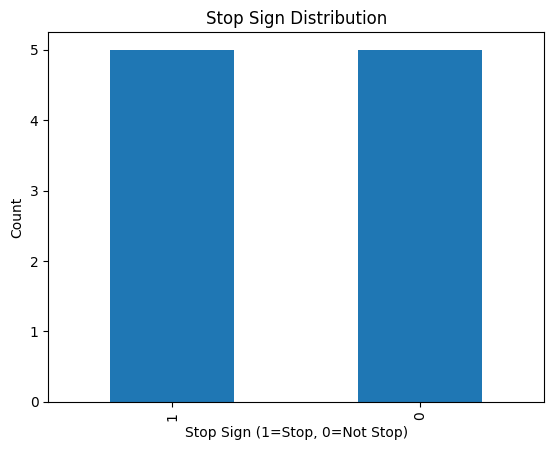

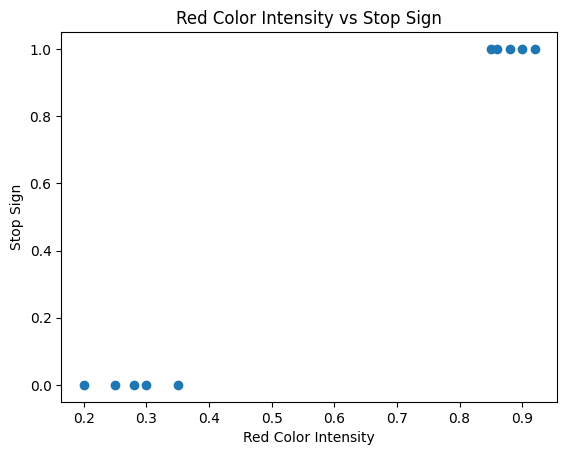

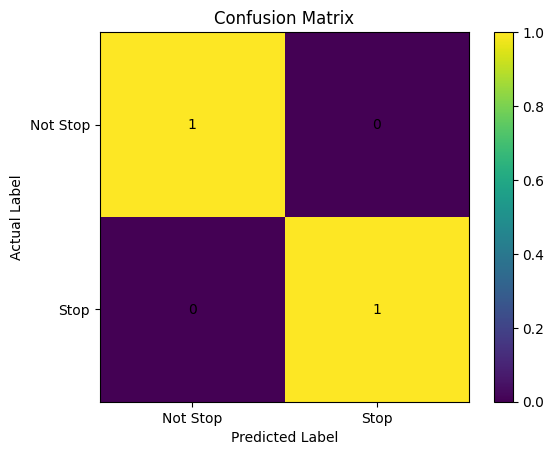

In [12]:
import matplotlib.pyplot as plt

df["Stop_Sign"].value_counts().plot(kind="bar")

plt.title("Stop Sign Distribution")
plt.xlabel("Stop Sign (1=Stop, 0=Not Stop)")
plt.ylabel("Count")
plt.show()

plt.scatter(df["Red_Color_Intensity"], df["Stop_Sign"])
plt.xlabel("Red Color Intensity")
plt.ylabel("Stop Sign")
plt.title("Red Color Intensity vs Stop Sign")
plt.show()

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0,1], ["Not Stop","Stop"])
plt.yticks([0,1], ["Not Stop","Stop"])

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.colorbar()
plt.show()